# 08 — Primary k = 2 feature characterization

**Notebook 8 of 9 — Drosophila book-chapter production pipeline**

**Purpose:** Characterize the accepted k = 2 unanimous consensus and majority assignments across the finalized 45-feature matrix.

**Primary inputs:** `data/processed/drosophila_features_reduced.csv`; `data/processed/k2_consensus_assignments.csv`; `data/processed/k2_unanimous_consensus_cells.csv`; `data/processed/multi_level_combined_nonimputed_normalized.csv`

**Primary outputs:** `data/processed/k2_stage1_unanimous_feature_characterization.csv`; `data/processed/k2_stage2_majority_feature_characterization.csv`; `data/processed/k2_stage1_vs_stage2_feature_robustness.csv`; `figures/Book_Chapter_Fig_4.png`; `figures/Book_Chapter_Fig_4.tiff`

**Manuscript role:** Primary k = 2 feature results and robustness analysis; produces Book Chapter Figure 4.

**Project authors:** Tim Rogalsky, Nicolas Malagon, Lia Campbell-Enns, Matthaeus Dyck

**Reproducibility:** Designed for fresh-kernel execution in production order 01→09 using repository-relative paths. It consumes explicit feature and consensus interfaces written by Notebooks 01, 04, and 07 and requires no private, diagnostic, or obsolete provenance artifact.

This is post-selection characterization; movie-specific analyses are robustness checks conditional on the three observed movies, not independent replication.

## 1. Analysis specification

Stage 1 characterizes the 88 cells in the unanimous consensus (`K2_U1`, n = 29; `K2_U2`, n = 59). Stage 2 repeats the analysis for all 108 majority assignments (`K2_M1`, n = 39; `K2_M2`, n = 69). Effects are oriented as the second canonical group minus the first. These groups are computational consensus assignments, not biological cell types.

In [1]:
from pathlib import Path
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import statsmodels
from PIL import Image
from scipy.stats import mannwhitneyu, pearsonr, rankdata, spearmanr
from statsmodels.stats.multitest import multipletests

FEATURE_PATH = Path('data/processed/drosophila_features_reduced.csv')
CONSENSUS_PATH = Path('data/processed/k2_consensus_assignments.csv')
UNANIMOUS_PATH = Path('data/processed/k2_unanimous_consensus_cells.csv')
MOVIE_SOURCE_PATH = Path('data/processed/multi_level_combined_nonimputed_normalized.csv')
STAGE1_PATH = Path('data/processed/k2_stage1_unanimous_feature_characterization.csv')
STAGE2_PATH = Path('data/processed/k2_stage2_majority_feature_characterization.csv')
ROBUSTNESS_PATH = Path('data/processed/k2_stage1_vs_stage2_feature_robustness.csv')
COMPOSITION_PATH = Path('data/processed/k2_feature_group_movie_composition.csv')
SUMMARY_PATH = Path('data/processed/k2_feature_characterization_manuscript_summary.csv')
FIGURE_PNG = Path('figures/Book_Chapter_Fig_4.png')
FIGURE_TIFF = Path('figures/Book_Chapter_Fig_4.tiff')
MOVIE_ORDER = ['Mov. 1', 'Mov. 2', 'Mov. 3']
BOOTSTRAP_REPLICATES = 5000
PERMUTATION_REPLICATES = 10000
BOOTSTRAP_SEED = 20260823
PERMUTATION_SEED = 20260824
SIGN_TOLERANCE = 1e-15
FEATURE_SCHEMA = [
    'a_mean', 'a_std', 'a_median', 'a_skew', 'a_kurtosis',
    'b_dominant_freq', 'b_band_power_low', 'b_band_power_mid',
    'b_band_power_high', 'b_spectral_entropy', 'b_spectral_flatness',
    'c_avg_time_between_peaks', 'c_std_time_between_peaks',
    'c_std_time_between_troughs', 'c_mean_peak_to_trough_time',
    'c_mean_trough_to_peak_time', 'd_slope_magnitude', 'd_poly_mag_c0',
    'd_poly_mag_c1', 'd_poly_mag_c2', 'd_poly_mag_c3', 'd_poly_peak_c0',
    'd_poly_peak_c1', 'd_poly_peak_c2', 'd_poly_peak_c3',
    'd_poly_trough_c0', 'd_poly_trough_c1', 'd_poly_trough_c2',
    'd_poly_trough_c3', 'd_initial_magnitude', 'd_final_magnitude',
    'd_initial_peak_to_trough_magnitude', 'd_final_peak_to_trough_magnitude',
    'e_autocorr_lag1', 'e_autocorr_lagk', 'e_hurst_exponent',
    'f_early_mean', 'f_late_mean', 'f_early_std', 'f_late_std',
    'f_early_autocorr', 'f_late_autocorr', 'f_delta_mean',
    'g_asymmetry_index', 'g_sharpness_index',
]
TOP10_FEATURES = [
    'a_std', 'g_sharpness_index', 'f_early_std',
    'd_initial_peak_to_trough_magnitude', 'd_slope_magnitude',
    'd_initial_magnitude', 'b_band_power_high', 'b_band_power_mid',
    'f_late_std', 'd_poly_peak_c3',
]
print({
    'Python': platform.python_version(), 'numpy': np.__version__,
    'pandas': pd.__version__, 'scipy': scipy.__version__,
    'statsmodels': statsmodels.__version__, 'matplotlib': matplotlib.__version__,
})

{'Python': '3.12.10', 'numpy': '2.1.3', 'pandas': '2.2.3', 'scipy': '1.15.3', 'statsmodels': '0.14.4', 'matplotlib': '3.10.0'}


## 2. Imports, paths, and reproducibility controls

The code declares the exact 45-feature order, 5,000 movie-stratified bootstrap replicates (`seed=20260823`), and 10,000 movie-stratified permutation replicates (`seed=20260824`). All paths are repository-relative production interfaces.

## 3. Load and validate production inputs

The reduced feature matrix supplies 108 cells × 45 features. Notebook-07 consensus files supply unanimous and majority membership, and the delta-only MultiIndex interface supplies movie identity. Assertions require exact cell sets, order, schemas, and complete finite feature values.

In [2]:
feature_raw = pd.read_csv(FEATURE_PATH)
identifier_column = feature_raw.columns[0]
features = feature_raw.rename(columns={identifier_column: 'Cell_Name'}).copy()
consensus = pd.read_csv(CONSENSUS_PATH)
unanimous_file = pd.read_csv(UNANIMOUS_PATH)

assert features.shape == (108, 46), features.shape
assert features.columns[1:].tolist() == FEATURE_SCHEMA, 'Ordered 45-feature schema mismatch.'
assert features['Cell_Name'].notna().all() and features['Cell_Name'].nunique() == 108
assert not features['Cell_Name'].duplicated().any()
assert consensus.shape[0] == 108 and consensus['Cell_Name'].nunique() == 108
assert not consensus['Cell_Name'].duplicated().any()
assert features['Cell_Name'].tolist() == consensus['Cell_Name'].tolist(), 'Feature/consensus cell order differs.'
assert set(features['Cell_Name']) == set(consensus['Cell_Name'])
assert consensus['K2_Majority_Group'].notna().all()
assert unanimous_file.shape[0] == 88 and unanimous_file['Cell_Name'].nunique() == 88
assert unanimous_file[['Cell_Name', 'K2_Unanimous_Group']].notna().all().all()
feature_values = features[FEATURE_SCHEMA].to_numpy(dtype=float)
assert np.isfinite(feature_values).all(), 'Non-finite feature values found.'
assert all(pd.api.types.is_numeric_dtype(features[c]) for c in FEATURE_SCHEMA)

unanimous_consensus = consensus.loc[consensus['K2_Consensus_Count'].eq(5)].copy()
assert len(unanimous_consensus) == 88
assert unanimous_file['Cell_Name'].tolist() == unanimous_consensus['Cell_Name'].tolist()
for column in ['K2_DW', 'K2_DK', 'K2_PK', 'K2_NH', 'K2_NK', 'K2_Strict_Signature', 'K2_Unanimous_Group']:
    assert unanimous_file[column].tolist() == unanimous_consensus[column].tolist(), column
assert unanimous_consensus['K2_Unanimous_Group'].notna().all()
assert consensus.loc[~consensus['K2_Consensus_Count'].eq(5), 'K2_Unanimous_Group'].isna().all()

print(f'Feature matrix: {features.shape[0]} cells x {len(FEATURE_SCHEMA)} features')
print(f'Consensus universe: {len(consensus)} cells; unanimous subset: {len(unanimous_file)} cells')

Feature matrix: 108 cells x 45 features
Consensus universe: 108 cells; unanimous subset: 88 cells


## 4. Validate k = 2 groups and movie composition

The unanimous and majority memberships are matched cell-for-cell to the feature matrix. Movie counts are retained for stratified uncertainty, permutation inference, and within-movie directional checks.

In [3]:
assert unanimous_file['K2_Unanimous_Group'].value_counts().to_dict() == {'K2_U2': 59, 'K2_U1': 29}
assert consensus['K2_Majority_Group'].value_counts().to_dict() == {'K2_M2': 69, 'K2_M1': 39}
signature_map = unanimous_file.groupby('K2_Unanimous_Group')['K2_Strict_Signature'].unique().apply(list).to_dict()
assert signature_map == {
    'K2_U1': ['K2-DW1-DK1-PK2-NH1-NK1'],
    'K2_U2': ['K2-DW2-DK2-PK1-NH2-NK2'],
}
movie_source = pd.read_csv(MOVIE_SOURCE_PATH, header=[0, 1, 2], index_col=0)
assert list(movie_source.columns.names) == ['Movie', 'Cell', 'Trend']
movie_mapping = pd.DataFrame([
    {'Cell_Name': f'{movie} - {cell}', 'Movie': movie}
    for movie, cell, _trend in movie_source.columns
]).drop_duplicates(ignore_index=True)
assert movie_mapping['Cell_Name'].is_unique
assert set(features['Cell_Name']) <= set(movie_mapping['Cell_Name'])

stage1_data = unanimous_consensus[['Cell_Name', 'K2_Unanimous_Group']].merge(
    features, on='Cell_Name', how='left', validate='one_to_one'
).merge(movie_mapping, on='Cell_Name', how='left', validate='one_to_one')
stage2_data = consensus[['Cell_Name', 'K2_Majority_Group']].merge(
    features, on='Cell_Name', how='left', validate='one_to_one'
).merge(movie_mapping, on='Cell_Name', how='left', validate='one_to_one')
assert len(stage1_data) == 88 and stage1_data['Cell_Name'].nunique() == 88
assert len(stage2_data) == 108 and stage2_data['Cell_Name'].nunique() == 108
assert stage1_data[['K2_Unanimous_Group', 'Movie', *FEATURE_SCHEMA]].notna().all().all()
assert stage2_data[['K2_Majority_Group', 'Movie', *FEATURE_SCHEMA]].notna().all().all()
stage1_counts = pd.crosstab(stage1_data['K2_Unanimous_Group'], stage1_data['Movie']).reindex(
    index=['K2_U1', 'K2_U2'], columns=MOVIE_ORDER, fill_value=0
)
stage2_counts = pd.crosstab(stage2_data['K2_Majority_Group'], stage2_data['Movie']).reindex(
    index=['K2_M1', 'K2_M2'], columns=MOVIE_ORDER, fill_value=0
)
assert stage1_counts.loc['K2_U1'].tolist() == [3, 7, 19]
assert stage1_counts.loc['K2_U2'].tolist() == [22, 20, 17]
assert stage2_counts.loc['K2_M1'].tolist() == [3, 8, 28]
assert stage2_counts.loc['K2_M2'].tolist() == [23, 24, 22]
movie_composition = pd.DataFrame([
    {'Stage': 'Stage1', 'Group': 'K2_U1', 'Movie1_n': 3, 'Movie2_n': 7, 'Movie3_n': 19, 'Total_n': 29},
    {'Stage': 'Stage1', 'Group': 'K2_U2', 'Movie1_n': 22, 'Movie2_n': 20, 'Movie3_n': 17, 'Total_n': 59},
    {'Stage': 'Stage2', 'Group': 'K2_M1', 'Movie1_n': 3, 'Movie2_n': 8, 'Movie3_n': 28, 'Total_n': 39},
    {'Stage': 'Stage2', 'Group': 'K2_M2', 'Movie1_n': 23, 'Movie2_n': 24, 'Movie3_n': 22, 'Total_n': 69},
])
display(movie_composition)

,Stage,Group,Movie1_n,Movie2_n,Movie3_n,Total_n
0,Stage1,K2_U1,3,7,19,29
1,Stage1,K2_U2,22,20,17,59
2,Stage2,K2_M1,3,8,28,39
3,Stage2,K2_M2,23,24,22,69


## 5. Statistical workflow

For each feature and stage, the notebook reports group descriptives, the Hodges–Lehmann shift, Cliff's delta, a two-sided Mann–Whitney test, and BH adjustment across 45 features. Movie-stratified bootstrap intervals preserve group-by-movie sample sizes; within-movie Cliff's deltas test directional consistency. A movie-stratified label permutation produces a weighted stratified delta and BH-adjusted permutation result. Bootstrap and permutation draws are shared across features within a stage, and each stage reinitializes its fixed RNG stream.

In [4]:
def pairwise_differences(first, second):
    return np.asarray(second, dtype=float)[:, None] - np.asarray(first, dtype=float)[None, :]

def cliffs_delta(first, second):
    differences = pairwise_differences(first, second)
    return (np.count_nonzero(differences > 0) - np.count_nonzero(differences < 0)) / differences.size

def hodges_lehmann_shift(first, second):
    return float(np.median(pairwise_differences(first, second)))

def numeric_sign(value, tolerance=SIGN_TOLERANCE):
    return 1 if value > tolerance else -1 if value < -tolerance else 0

def direction_label(value):
    return {1: 'positive', -1: 'negative', 0: 'zero'}[numeric_sign(value)]

def characterize_stage(data, group_column, first_group, second_group, rank_column):
    assert BOOTSTRAP_REPLICATES == 5000 and PERMUTATION_REPLICATES == 10000
    assert BOOTSTRAP_SEED == 20260823 and PERMUTATION_SEED == 20260824
    first_n = int((data[group_column] == first_group).sum())
    second_n = int((data[group_column] == second_group).sum())
    pooled_rows = []
    for feature in FEATURE_SCHEMA:
        first = data.loc[data[group_column] == first_group, feature].to_numpy(dtype=float)
        second = data.loc[data[group_column] == second_group, feature].to_numpy(dtype=float)
        assert len(first) == first_n and len(second) == second_n
        mw = mannwhitneyu(first, second, alternative='two-sided', method='asymptotic')
        first_q1, first_q3 = np.quantile(first, [0.25, 0.75])
        second_q1, second_q3 = np.quantile(second, [0.25, 0.75])
        pooled_rows.append({
            'Feature': feature, f'{first_group}_n': first_n, f'{second_group}_n': second_n,
            f'{first_group}_Median': np.median(first), f'{first_group}_Q1': first_q1,
            f'{first_group}_Q3': first_q3, f'{first_group}_IQR': first_q3 - first_q1,
            f'{second_group}_Median': np.median(second), f'{second_group}_Q1': second_q1,
            f'{second_group}_Q3': second_q3, f'{second_group}_IQR': second_q3 - second_q1,
            f'{first_group}_Mean': np.mean(first), f'{first_group}_SD': np.std(first, ddof=1),
            f'{second_group}_Mean': np.mean(second), f'{second_group}_SD': np.std(second, ddof=1),
            f'HL_Shift_{second_group}_minus_{first_group}': hodges_lehmann_shift(first, second),
            f'Cliffs_Delta_{second_group}_vs_{first_group}': cliffs_delta(first, second),
            f'MannWhitney_U_{first_group}': float(mw.statistic), 'MW_p': float(mw.pvalue),
        })
    results = pd.DataFrame(pooled_rows)
    results['MW_BH_q'] = multipletests(results['MW_p'], method='fdr_bh')[1]

    positions = np.arange(len(data))
    bootstrap_rng = np.random.default_rng(BOOTSTRAP_SEED)
    def bootstrap_indices(group):
        pieces = []
        for movie in MOVIE_ORDER:
            indices = positions[(data[group_column].to_numpy() == group) & (data['Movie'].to_numpy() == movie)]
            assert len(indices) > 0
            pieces.append(bootstrap_rng.choice(indices, size=(BOOTSTRAP_REPLICATES, len(indices)), replace=True))
        return np.concatenate(pieces, axis=1)
    boot_first = bootstrap_indices(first_group)
    boot_second = bootstrap_indices(second_group)
    assert boot_first.shape == (BOOTSTRAP_REPLICATES, first_n)
    assert boot_second.shape == (BOOTSTRAP_REPLICATES, second_n)
    bootstrap_rows = []
    for feature in FEATURE_SCHEMA:
        values = data[feature].to_numpy(dtype=float)
        delta_reps = np.empty(BOOTSTRAP_REPLICATES)
        hl_reps = np.empty(BOOTSTRAP_REPLICATES)
        for start in range(0, BOOTSTRAP_REPLICATES, 250):
            stop = min(start + 250, BOOTSTRAP_REPLICATES)
            first_samples = values[boot_first[start:stop]]
            second_samples = values[boot_second[start:stop]]
            differences = second_samples[:, :, None] - first_samples[:, None, :]
            delta_reps[start:stop] = (
                np.count_nonzero(differences > 0, axis=(1, 2))
                - np.count_nonzero(differences < 0, axis=(1, 2))
            ) / (first_n * second_n)
            hl_reps[start:stop] = np.median(differences, axis=(1, 2))
        bootstrap_rows.append({
            'Feature': feature, 'HL_CI_Lower': np.quantile(hl_reps, 0.025),
            'HL_CI_Upper': np.quantile(hl_reps, 0.975),
            'Delta_CI_Lower': np.quantile(delta_reps, 0.025),
            'Delta_CI_Upper': np.quantile(delta_reps, 0.975),
        })
    results = results.merge(pd.DataFrame(bootstrap_rows), on='Feature', validate='one_to_one')

    within_rows = []
    for feature in FEATURE_SCHEMA:
        for movie_number, movie in enumerate(MOVIE_ORDER, start=1):
            subset = data.loc[data['Movie'] == movie]
            first = subset.loc[subset[group_column] == first_group, feature].to_numpy(dtype=float)
            second = subset.loc[subset[group_column] == second_group, feature].to_numpy(dtype=float)
            delta = cliffs_delta(first, second)
            within_rows.append({
                'Feature': feature, 'Movie': movie, 'Movie_Number': movie_number,
                'First_n': len(first), 'Second_n': len(second),
                'First_Median': np.median(first), 'Second_Median': np.median(second),
                'HL_Shift': hodges_lehmann_shift(first, second),
                'Cliffs_Delta': delta, 'Delta_Sign': direction_label(delta),
            })
    within = pd.DataFrame(within_rows)
    assert len(within) == 135
    for movie_number, movie in enumerate(MOVIE_ORDER, start=1):
        lookup = within.loc[within['Movie'] == movie].set_index('Feature')
        results[f'Movie{movie_number}_Delta'] = results['Feature'].map(lookup['Cliffs_Delta'])
        results[f'Movie{movie_number}_Delta_Sign'] = results['Feature'].map(lookup['Delta_Sign'])

    matching_counts, consistency, reversals = [], [], []
    delta_column = f'Cliffs_Delta_{second_group}_vs_{first_group}'
    for row in results.itertuples(index=False):
        pooled_sign = numeric_sign(getattr(row, delta_column))
        movie_signs = [numeric_sign(getattr(row, f'Movie{i}_Delta')) for i in range(1, 4)]
        matches = sum(sign == pooled_sign for sign in movie_signs) if pooled_sign != 0 else 0
        matching_counts.append(matches)
        consistency.append(bool(pooled_sign != 0 and matches == 3))
        reversals.append(bool(pooled_sign != 0 and any(sign not in (0, pooled_sign) for sign in movie_signs)))
    results['Movies_Matching_Pooled_Direction'] = matching_counts
    results['Direction_Consistent_All_Movies'] = consistency
    results['Any_Movie_Direction_Reversal'] = reversals

    permutation_rng = np.random.default_rng(PERMUTATION_SEED)
    movie_masks, movie_indices, movie_weights = {}, {}, {}
    for movie in MOVIE_ORDER:
        indices = positions[data['Movie'].to_numpy() == movie]
        movie_indices[movie] = indices
        n_second = int((data.iloc[indices][group_column] == second_group).sum())
        n_first = len(indices) - n_second
        movie_weights[movie] = n_first * n_second
        priorities = permutation_rng.random((PERMUTATION_REPLICATES, len(indices)))
        selected = np.argpartition(priorities, kth=n_second - 1, axis=1)[:, :n_second]
        masks = np.zeros((PERMUTATION_REPLICATES, len(indices)), dtype=np.uint8)
        masks[np.arange(PERMUTATION_REPLICATES)[:, None], selected] = 1
        assert (masks.sum(axis=1) == n_second).all()
        movie_masks[movie] = masks
    total_weight = sum(movie_weights.values())
    permutation_rows = []
    for feature in FEATURE_SCHEMA:
        observed_sum = 0.0
        permutation_sum = np.zeros(PERMUTATION_REPLICATES)
        for movie in MOVIE_ORDER:
            indices = movie_indices[movie]
            values = data.iloc[indices][feature].to_numpy(dtype=float)
            observed_second = (data.iloc[indices][group_column].to_numpy() == second_group).astype(np.uint8)
            n_second = int(observed_second.sum())
            n_first = len(values) - n_second
            weight = n_first * n_second
            ranks = rankdata(values, method='average')
            observed_u_second = observed_second @ ranks - n_second * (n_second + 1) / 2
            observed_delta = 2 * observed_u_second / weight - 1
            direct_delta = within.loc[(within['Feature'] == feature) & (within['Movie'] == movie), 'Cliffs_Delta'].iloc[0]
            assert np.isclose(observed_delta, direct_delta, rtol=0, atol=1e-12)
            perm_u_second = movie_masks[movie] @ ranks - n_second * (n_second + 1) / 2
            perm_delta = 2 * perm_u_second / weight - 1
            observed_sum += weight * observed_delta
            permutation_sum += weight * perm_delta
        observed_statistic = observed_sum / total_weight
        permutation_statistics = permutation_sum / total_weight
        exceedances = int(np.count_nonzero(
            np.abs(permutation_statistics) >= abs(observed_statistic) - SIGN_TOLERANCE
        ))
        permutation_rows.append({
            'Feature': feature, 'Stratified_Delta': observed_statistic,
            'Stratified_Permutation_p': (1 + exceedances) / (PERMUTATION_REPLICATES + 1),
        })
    permutation = pd.DataFrame(permutation_rows)
    permutation['Stratified_BH_q'] = multipletests(permutation['Stratified_Permutation_p'], method='fdr_bh')[1]
    results = results.merge(permutation, on='Feature', validate='one_to_one')
    results = results.sort_values([delta_column, 'Feature'], key=lambda s: s.abs() if s.name == delta_column else s, ascending=[False, True], ignore_index=True)
    results[rank_column] = np.arange(1, 46)

    columns = [
        'Feature', f'{first_group}_n', f'{second_group}_n',
        f'{first_group}_Median', f'{first_group}_Q1', f'{first_group}_Q3', f'{first_group}_IQR',
        f'{second_group}_Median', f'{second_group}_Q1', f'{second_group}_Q3', f'{second_group}_IQR',
        f'{first_group}_Mean', f'{first_group}_SD', f'{second_group}_Mean', f'{second_group}_SD',
        f'HL_Shift_{second_group}_minus_{first_group}', 'HL_CI_Lower', 'HL_CI_Upper',
        delta_column, 'Delta_CI_Lower', 'Delta_CI_Upper', f'MannWhitney_U_{first_group}',
        'MW_p', 'MW_BH_q', 'Movie1_Delta', 'Movie1_Delta_Sign',
        'Movie2_Delta', 'Movie2_Delta_Sign', 'Movie3_Delta', 'Movie3_Delta_Sign',
        'Movies_Matching_Pooled_Direction', 'Direction_Consistent_All_Movies',
        'Any_Movie_Direction_Reversal', 'Stratified_Delta',
        'Stratified_Permutation_p', 'Stratified_BH_q', rank_column,
    ]
    return results[columns].copy(), within


## 6. Stage 1 — 88-cell unanimous consensus

Stage 1 compares `K2_U2` with `K2_U1` across all 45 features and ranks features by absolute pooled Cliff's delta.

In [5]:
stage1, stage1_within_movie = characterize_stage(
    stage1_data, 'K2_Unanimous_Group', 'K2_U1', 'K2_U2', 'Stage1_Abs_Rank'
)
assert stage1.shape == (45, 37)
display(stage1.head(10).round(6))

,Feature,K2_U1_n,K2_U2_n,K2_U1_Median,K2_U1_Q1,K2_U1_Q3,K2_U1_IQR,K2_U2_Median,K2_U2_Q1,K2_U2_Q3,...,Movie2_Delta_Sign,Movie3_Delta,Movie3_Delta_Sign,Movies_Matching_Pooled_Direction,Direction_Consistent_All_Movies,Any_Movie_Direction_Reversal,Stratified_Delta,Stratified_Permutation_p,Stratified_BH_q,Stage1_Abs_Rank
0,a_std,29,59,0.719146,0.671142,0.791547,0.120404,0.212600,0.088893,0.335229,...,negative,-1.000000,negative,3,True,False,-1.000000,0.0001,0.000562,1
1,g_sharpness_index,29,59,0.620576,0.558809,0.722144,0.163335,0.188211,0.074026,0.267620,...,negative,-0.975232,negative,3,True,False,-0.984877,0.0001,0.000562,2
2,f_early_std,29,59,0.629643,0.544264,0.730779,0.186515,0.174148,0.088717,0.242447,...,negative,-0.900929,negative,3,True,False,-0.931947,0.0001,0.000562,3
3,d_initial_peak_to_trough_magnitude,29,59,0.705667,0.592769,0.855317,0.262548,0.169822,0.065237,0.259123,...,negative,-0.944272,negative,3,True,False,-0.928166,0.0001,0.000562,4
4,d_slope_magnitude,29,59,0.433084,0.307627,0.597556,0.289929,0.764737,0.714573,0.815653,...,positive,0.962848,positive,3,True,False,0.947070,0.0001,0.000562,5
5,d_initial_magnitude,29,59,0.493362,0.268883,0.604971,0.336088,0.120849,0.067627,0.171051,...,negative,-0.913313,negative,3,True,False,-0.913043,0.0001,0.000562,6
6,b_band_power_high,29,59,0.261571,0.156648,0.324769,0.168121,0.059361,0.025575,0.084808,...,negative,-0.758514,negative,3,True,False,-0.826087,0.0001,0.000562,7
7,b_band_power_mid,29,59,0.073350,0.035844,0.164497,0.128652,0.012512,0.004314,0.031698,...,negative,-0.634675,negative,3,True,False,-0.674858,0.0001,0.000562,8
8,f_late_std,29,59,0.253868,0.165388,0.313302,0.147914,0.122707,0.049907,0.216660,...,negative,-0.393189,negative,3,True,False,-0.463138,0.0013,0.004178,9
9,d_poly_peak_c3,29,59,0.561087,0.457432,0.689795,0.232363,0.420124,0.337640,0.477112,...,negative,-0.653251,negative,3,True,False,-0.523629,0.0006,0.002700,10


## 7. Stage 1 movie-stratified robustness

The Stage-1 table includes 5,000-replicate movie-stratified bootstrap intervals, all three within-movie effects, and 10,000-replicate movie-stratified permutation inference.

## 8. Stage 2 — 108-cell majority assignment

Stage 2 applies the same workflow to `K2_M2` versus `K2_M1`, extending characterization from the unanimous subset to every retained cell.

In [6]:
stage2, stage2_within_movie = characterize_stage(
    stage2_data, 'K2_Majority_Group', 'K2_M1', 'K2_M2', 'Stage2_Abs_Rank'
)
assert stage2.shape == (45, 37)
display(stage2.head(10).round(6))

,Feature,K2_M1_n,K2_M2_n,K2_M1_Median,K2_M1_Q1,K2_M1_Q3,K2_M1_IQR,K2_M2_Median,K2_M2_Q1,K2_M2_Q3,...,Movie2_Delta_Sign,Movie3_Delta,Movie3_Delta_Sign,Movies_Matching_Pooled_Direction,Direction_Consistent_All_Movies,Any_Movie_Direction_Reversal,Stratified_Delta,Stratified_Permutation_p,Stratified_BH_q,Stage2_Abs_Rank
0,a_std,39,69,0.708191,0.641375,0.778125,0.136750,0.283513,0.094076,0.387401,...,negative,-0.941558,negative,3,True,False,-0.958951,0.0001,0.0005,1
1,g_sharpness_index,39,69,0.611750,0.525593,0.685282,0.159688,0.208515,0.078552,0.299128,...,negative,-0.873377,negative,3,True,False,-0.911060,0.0001,0.0005,2
2,f_early_std,39,69,0.611699,0.442574,0.719980,0.277406,0.192359,0.099380,0.286103,...,negative,-0.818182,negative,3,True,False,-0.867731,0.0001,0.0005,3
3,d_initial_peak_to_trough_magnitude,39,69,0.665394,0.481237,0.820509,0.339272,0.187561,0.076626,0.264164,...,negative,-0.918831,negative,3,True,False,-0.911060,0.0001,0.0005,4
4,d_slope_magnitude,39,69,0.458977,0.325192,0.615220,0.290029,0.765965,0.714305,0.816757,...,positive,0.860390,positive,3,True,False,0.881414,0.0001,0.0005,5
5,d_initial_magnitude,39,69,0.421877,0.242876,0.574716,0.331839,0.120849,0.079870,0.197452,...,negative,-0.788961,negative,3,True,False,-0.819840,0.0001,0.0005,6
6,b_band_power_high,39,69,0.261571,0.158410,0.339735,0.181326,0.067352,0.029447,0.113659,...,negative,-0.597403,negative,3,True,False,-0.671608,0.0001,0.0005,7
7,b_band_power_mid,39,69,0.076735,0.046596,0.125188,0.078592,0.014091,0.004378,0.044374,...,negative,-0.581169,negative,3,True,False,-0.578107,0.0001,0.0005,8
8,d_poly_peak_c2,39,69,0.469872,0.351317,0.542627,0.191311,0.650344,0.555361,0.716912,...,positive,0.672078,positive,3,True,False,0.548461,0.0001,0.0005,9
9,d_poly_peak_c3,39,69,0.561087,0.477283,0.687397,0.210115,0.428067,0.335579,0.486639,...,negative,-0.672078,negative,3,True,False,-0.548461,0.0002,0.0009,10


## 9. Stage-1 versus Stage-2 robustness

The comparison records effect attenuation, direction preservation, rank changes, bootstrap-interval behavior, within-movie consistency, and Pearson/Spearman concordance between the unanimous-consensus and majority-assignment effects.

In [7]:
stage1_delta = 'Cliffs_Delta_K2_U2_vs_K2_U1'
stage2_delta = 'Cliffs_Delta_K2_M2_vs_K2_M1'
s1 = stage1.set_index('Feature')
s2 = stage2.set_index('Feature')
robustness = pd.DataFrame({'Feature': stage1['Feature']})
robustness['Stage1_Delta'] = robustness['Feature'].map(s1[stage1_delta])
robustness['Stage2_Delta'] = robustness['Feature'].map(s2[stage2_delta])
robustness['Stage1_Abs_Delta'] = robustness['Stage1_Delta'].abs()
robustness['Stage2_Abs_Delta'] = robustness['Stage2_Delta'].abs()
robustness['Stage1_Abs_Rank'] = robustness['Feature'].map(s1['Stage1_Abs_Rank']).astype(int)
robustness['Stage2_Abs_Rank'] = robustness['Feature'].map(s2['Stage2_Abs_Rank']).astype(int)
robustness['Stage1_HL_Shift'] = robustness['Feature'].map(s1['HL_Shift_K2_U2_minus_K2_U1'])
robustness['Stage2_HL_Shift'] = robustness['Feature'].map(s2['HL_Shift_K2_M2_minus_K2_M1'])
for target, source, table in [
    ('Stage1_Delta_CI_Lower', 'Delta_CI_Lower', s1), ('Stage1_Delta_CI_Upper', 'Delta_CI_Upper', s1),
    ('Stage2_Delta_CI_Lower', 'Delta_CI_Lower', s2), ('Stage2_Delta_CI_Upper', 'Delta_CI_Upper', s2),
]:
    robustness[target] = robustness['Feature'].map(table[source])
robustness['Delta_Change'] = robustness['Stage2_Delta'] - robustness['Stage1_Delta']
robustness['Abs_Delta_Change'] = robustness['Stage2_Abs_Delta'] - robustness['Stage1_Abs_Delta']
robustness['Abs_Delta_Ratio'] = np.where(robustness['Stage1_Abs_Delta'] > 0, robustness['Stage2_Abs_Delta'] / robustness['Stage1_Abs_Delta'], np.nan)
robustness['Percent_Attenuation'] = np.where(
    robustness['Stage1_Abs_Delta'] > 0,
    100 * (robustness['Stage1_Abs_Delta'] - robustness['Stage2_Abs_Delta']) / robustness['Stage1_Abs_Delta'],
    np.nan,
)
robustness['Delta_Direction_Preserved'] = [numeric_sign(a) == numeric_sign(b) for a, b in zip(robustness['Stage1_Delta'], robustness['Stage2_Delta'])]
robustness['Delta_Sign_Reversed'] = [numeric_sign(a) * numeric_sign(b) == -1 for a, b in zip(robustness['Stage1_Delta'], robustness['Stage2_Delta'])]
robustness['HL_Direction_Preserved'] = [numeric_sign(a) == numeric_sign(b) for a, b in zip(robustness['Stage1_HL_Shift'], robustness['Stage2_HL_Shift'])]
for stage, table in [('Stage1', s1), ('Stage2', s2)]:
    robustness[f'{stage}_MW_BH_q'] = robustness['Feature'].map(table['MW_BH_q'])
    robustness[f'{stage}_Stratified_BH_q'] = robustness['Feature'].map(table['Stratified_BH_q'])
    for movie_number in range(1, 4):
        robustness[f'{stage}_Movie{movie_number}_Delta'] = robustness['Feature'].map(table[f'Movie{movie_number}_Delta'])
    robustness[f'{stage}_Direction_Consistent_All_Movies'] = robustness['Feature'].map(table['Direction_Consistent_All_Movies']).astype(bool)
robustness['Stage2_Any_Movie_Direction_Reversal'] = robustness['Feature'].map(s2['Any_Movie_Direction_Reversal']).astype(bool)
robustness['Stage2_CI_Excludes_Zero'] = (robustness['Stage2_Delta_CI_Lower'] > 0) | (robustness['Stage2_Delta_CI_Upper'] < 0)
ROBUSTNESS_COLUMNS = [
    'Feature', 'Stage1_Delta', 'Stage2_Delta', 'Stage1_Abs_Delta', 'Stage2_Abs_Delta',
    'Stage1_Abs_Rank', 'Stage2_Abs_Rank', 'Stage1_HL_Shift', 'Stage2_HL_Shift',
    'Stage1_Delta_CI_Lower', 'Stage1_Delta_CI_Upper', 'Stage2_Delta_CI_Lower',
    'Stage2_Delta_CI_Upper', 'Delta_Change', 'Abs_Delta_Change', 'Abs_Delta_Ratio',
    'Percent_Attenuation', 'Delta_Direction_Preserved', 'Delta_Sign_Reversed',
    'HL_Direction_Preserved', 'Stage1_MW_BH_q', 'Stage2_MW_BH_q',
    'Stage1_Stratified_BH_q', 'Stage2_Stratified_BH_q',
    'Stage1_Movie1_Delta', 'Stage1_Movie2_Delta', 'Stage1_Movie3_Delta',
    'Stage2_Movie1_Delta', 'Stage2_Movie2_Delta', 'Stage2_Movie3_Delta',
    'Stage1_Direction_Consistent_All_Movies', 'Stage2_Direction_Consistent_All_Movies',
    'Stage2_Any_Movie_Direction_Reversal', 'Stage2_CI_Excludes_Zero',
]
robustness = robustness[ROBUSTNESS_COLUMNS].sort_values('Stage1_Abs_Rank', ignore_index=True)
assert robustness.shape == (45, 34)
display(robustness.head(10).round(6))

,Feature,Stage1_Delta,Stage2_Delta,Stage1_Abs_Delta,Stage2_Abs_Delta,Stage1_Abs_Rank,Stage2_Abs_Rank,Stage1_HL_Shift,Stage2_HL_Shift,Stage1_Delta_CI_Lower,...,Stage1_Movie1_Delta,Stage1_Movie2_Delta,Stage1_Movie3_Delta,Stage2_Movie1_Delta,Stage2_Movie2_Delta,Stage2_Movie3_Delta,Stage1_Direction_Consistent_All_Movies,Stage2_Direction_Consistent_All_Movies,Stage2_Any_Movie_Direction_Reversal,Stage2_CI_Excludes_Zero
0,a_std,-1.000000,-0.979190,1.000000,0.979190,1,1,-0.533045,-0.444546,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.941558,True,True,False,True
1,g_sharpness_index,-0.995324,-0.953177,0.995324,0.953177,2,2,-0.455896,-0.401862,-1.000000,...,-1.000000,-1.000000,-0.975232,-1.000000,-1.000000,-0.873377,True,True,False,True
2,f_early_std,-0.959088,-0.930881,0.959088,0.930881,3,3,-0.459056,-0.390633,-0.991818,...,-1.000000,-0.971429,-0.900929,-1.000000,-0.979167,-0.818182,True,True,False,True
3,d_initial_peak_to_trough_magnitude,-0.928697,-0.913787,0.928697,0.913787,4,4,-0.554754,-0.451437,-0.994155,...,-1.000000,-0.857143,-0.944272,-1.000000,-0.854167,-0.918831,True,True,False,True
4,d_slope_magnitude,0.918177,0.841695,0.918177,0.841695,5,5,0.338006,0.290032,0.829340,...,1.000000,0.885714,0.962848,1.000000,0.906250,0.860390,True,True,False,True
5,d_initial_magnitude,-0.891292,-0.826087,0.891292,0.826087,6,6,-0.331778,-0.257079,-0.961426,...,-1.000000,-0.871429,-0.913313,-1.000000,-0.854167,-0.788961,True,True,False,True
6,b_band_power_high,-0.887785,-0.780751,0.887785,0.780751,7,7,-0.182216,-0.164158,-0.961426,...,-0.969697,-0.914286,-0.758514,-0.971014,-0.802083,-0.597403,True,True,False,True
7,b_band_power_mid,-0.756867,-0.689335,0.756867,0.689335,8,8,-0.056195,-0.055757,-0.877265,...,-0.787879,-0.714286,-0.634675,-0.797101,-0.489583,-0.581169,True,True,False,True
8,f_late_std,-0.563998,-0.469342,0.563998,0.469342,9,12,-0.113689,-0.093720,-0.745178,...,-0.666667,-0.528571,-0.393189,-0.652174,-0.333333,-0.288961,True,True,False,True
9,d_poly_peak_c3,-0.555815,-0.554069,0.555815,0.554069,10,10,-0.166500,-0.157875,-0.754530,...,-0.727273,-0.128571,-0.653251,-0.739130,-0.083333,-0.672078,True,True,False,True


## 10. Production CSV outputs

The notebook writes the complete Stage-1 and Stage-2 feature tables, their feature-by-feature robustness comparison, group-by-movie composition, and a compact manuscript summary of the ten leading Stage-1 effects.

In [8]:
FEATURE_LABELS = {
    'a_std': 'Standard deviation',
    'g_sharpness_index': 'Sharpness index',
    'f_early_std': 'Early standard deviation',
    'd_initial_peak_to_trough_magnitude': 'Initial fall amplitude',
    'd_slope_magnitude': 'Slope of oscillation magnitude',
    'd_initial_magnitude': 'Initial oscillation strength',
    'b_band_power_high': 'High-frequency band power',
    'b_band_power_mid': 'Mid-frequency band power',
    'f_late_std': 'Late standard deviation',
    'd_poly_peak_c3': 'Peak-magnitude polynomial coefficient (c3)',
}
summary = pd.DataFrame({'Feature': TOP10_FEATURES})
summary['Feature_Label'] = summary['Feature'].map(FEATURE_LABELS)
summary['Stage1_Abs_Rank'] = summary['Feature'].map(s1['Stage1_Abs_Rank']).astype(int)
summary['K2_U1_Median'] = summary['Feature'].map(s1['K2_U1_Median'])
summary['K2_U2_Median'] = summary['Feature'].map(s1['K2_U2_Median'])
summary['Stage1_Delta'] = summary['Feature'].map(s1[stage1_delta])
summary['Stage1_Delta_CI_Lower'] = summary['Feature'].map(s1['Delta_CI_Lower'])
summary['Stage1_Delta_CI_Upper'] = summary['Feature'].map(s1['Delta_CI_Upper'])
summary['Stage1_Stratified_BH_q'] = summary['Feature'].map(s1['Stratified_BH_q'])
summary['Stage1_Direction_Consistent_All_Movies'] = summary['Feature'].map(s1['Direction_Consistent_All_Movies']).astype(bool)
summary['Stage2_Delta'] = summary['Feature'].map(s2[stage2_delta])
summary['Stage2_Delta_CI_Lower'] = summary['Feature'].map(s2['Delta_CI_Lower'])
summary['Stage2_Delta_CI_Upper'] = summary['Feature'].map(s2['Delta_CI_Upper'])
summary['Stage2_Stratified_BH_q'] = summary['Feature'].map(s2['Stratified_BH_q'])
summary['Stage2_Direction_Consistent_All_Movies'] = summary['Feature'].map(s2['Direction_Consistent_All_Movies']).astype(bool)
summary['Percent_Attenuation'] = summary['Feature'].map(robustness.set_index('Feature')['Percent_Attenuation'])
assert summary.shape == (10, 16) and summary['Feature'].tolist() == TOP10_FEATURES

for path in [STAGE1_PATH, STAGE2_PATH, ROBUSTNESS_PATH, COMPOSITION_PATH, SUMMARY_PATH]:
    path.parent.mkdir(parents=True, exist_ok=True)
stage1.to_csv(STAGE1_PATH, index=False)
stage2.to_csv(STAGE2_PATH, index=False)
robustness.to_csv(ROBUSTNESS_PATH, index=False)
movie_composition.to_csv(COMPOSITION_PATH, index=False)
summary.to_csv(SUMMARY_PATH, index=False)
for path, expected_rows in [(STAGE1_PATH, 45), (STAGE2_PATH, 45), (ROBUSTNESS_PATH, 45), (COMPOSITION_PATH, 4), (SUMMARY_PATH, 10)]:
    exported = pd.read_csv(path)
    assert len(exported) == expected_rows and path.stat().st_size > 0
    print(f'{path}: {exported.shape[0]} x {exported.shape[1]}')

data\processed\k2_stage1_unanimous_feature_characterization.csv: 45 x 37
data\processed\k2_stage2_majority_feature_characterization.csv: 45 x 37
data\processed\k2_stage1_vs_stage2_feature_robustness.csv: 45 x 34
data\processed\k2_feature_group_movie_composition.csv: 4 x 6
data\processed\k2_feature_characterization_manuscript_summary.csv: 10 x 16


## 11. Book Chapter Figure 4

Figure 4 displays unanimous-consensus medians for the ten leading Stage-1 features and compares Stage-1 and Stage-2 Cliff's deltas with movie-stratified bootstrap intervals. PNG and LZW-compressed TIFF files are written at 600 dpi.

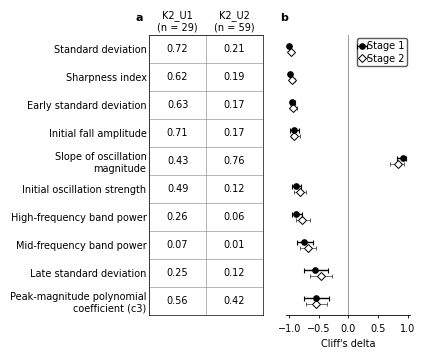

{'pixels': (2764, 2112), 'png_dpi': (599.9988, 599.9988), 'tiff_dpi': (600.0, 600.0), 'tiff_compression': 'tiff_lzw'}


In [9]:
plot_data = summary.set_index('Feature').loc[TOP10_FEATURES]
median_matrix = plot_data[['K2_U1_Median', 'K2_U2_Median']].to_numpy()
stage1_ci = np.vstack([plot_data['Stage1_Delta'] - plot_data['Stage1_Delta_CI_Lower'], plot_data['Stage1_Delta_CI_Upper'] - plot_data['Stage1_Delta']])
stage2_ci = np.vstack([plot_data['Stage2_Delta'] - plot_data['Stage2_Delta_CI_Lower'], plot_data['Stage2_Delta_CI_Upper'] - plot_data['Stage2_Delta']])
y = np.arange(len(TOP10_FEATURES))
FIG_DPI = 600
FIG_FONT_PT = 7
FIG_PANEL_PT = 8
FIG4_WIDTH_PX = 2764
FIG4_PREVIOUS_HEIGHT_PX = 2182
FIG4_BOTTOM_TRIM_PX = 70
FIG4_HEIGHT_PX = 2112
assert FIG4_HEIGHT_PX == FIG4_PREVIOUS_HEIGHT_PX - FIG4_BOTTOM_TRIM_PX
fig = plt.figure(
    figsize=(FIG4_WIDTH_PX / FIG_DPI, FIG4_HEIGHT_PX / FIG_DPI),
    facecolor='white',
)
grid_bottom = (0.14 * FIG4_PREVIOUS_HEIGHT_PX - FIG4_BOTTOM_TRIM_PX) / FIG4_HEIGHT_PX
grid_top = (0.91 * FIG4_PREVIOUS_HEIGHT_PX - FIG4_BOTTOM_TRIM_PX) / FIG4_HEIGHT_PX
grid = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.15], wspace=0.20, left=0.41, right=0.977, top=grid_top, bottom=grid_bottom)
ax_heat = fig.add_subplot(grid[0, 0])
ax_effect = fig.add_subplot(grid[0, 1], sharey=ax_heat)
ax_heat.set_facecolor('white')
ax_heat.set_xlim(-0.5, median_matrix.shape[1] - 0.5)
ax_heat.set_ylim(median_matrix.shape[0] - 0.5, -0.5)
ax_heat.vlines(np.arange(-0.5, median_matrix.shape[1] + 0.5, 1), -0.5, median_matrix.shape[0] - 0.5, colors='0.60', linewidth=0.5)
ax_heat.hlines(np.arange(-0.5, median_matrix.shape[0] + 0.5, 1), -0.5, median_matrix.shape[1] - 0.5, colors='0.60', linewidth=0.5)
ax_heat.set_xticks([0, 1], ['K2_U1\n(n = 29)', 'K2_U2\n(n = 59)'], fontsize=FIG_FONT_PT)
ax_heat.xaxis.tick_top()
figure_labels = [
    label.replace('Slope of oscillation magnitude', 'Slope of oscillation\nmagnitude')
    .replace('Peak-magnitude polynomial coefficient (c3)', 'Peak-magnitude polynomial\ncoefficient (c3)')
    for label in plot_data['Feature_Label']
]
ax_heat.set_yticks(y, figure_labels, fontsize=FIG_FONT_PT)
ax_heat.tick_params(axis='both', length=0, pad=2)
for row in range(median_matrix.shape[0]):
    for column in range(median_matrix.shape[1]):
        value = median_matrix[row, column]
        ax_heat.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=FIG_FONT_PT, color='black')
for spine in ax_heat.spines.values():
    spine.set_linewidth(0.5)
ax_heat.text(-0.12, 1.045, 'a', transform=ax_heat.transAxes, fontsize=FIG_PANEL_PT, fontweight='bold', va='bottom')

ax_effect.axvline(0, color='0.55', linewidth=0.6, zorder=0)
ax_effect.errorbar(plot_data['Stage1_Delta'], y - 0.12, xerr=stage1_ci, fmt='o', color='black', ecolor='black', markersize=3.8, elinewidth=1.0, capsize=1.8, capthick=0.8, label='Stage 1', zorder=3)
ax_effect.errorbar(plot_data['Stage2_Delta'], y + 0.12, xerr=stage2_ci, fmt='D', markerfacecolor='white', markeredgecolor='black', markeredgewidth=0.7, color='0.35', ecolor='0.35', linestyle='none', markersize=3.6, elinewidth=0.6, capsize=1.4, capthick=0.6, label='Stage 2', zorder=2)
ax_effect.set_xlim(-1.05, 1.05)
ax_effect.set_xticks([-1, -0.5, 0, 0.5, 1])
ax_effect.set_xlabel("Cliff's delta", fontsize=FIG_FONT_PT)
ax_effect.tick_params(axis='x', labelsize=FIG_FONT_PT, width=0.6, length=2.5)
ax_effect.tick_params(axis='y', left=False, labelleft=False)
ax_effect.spines[['top', 'right', 'left']].set_visible(False)
ax_effect.spines['bottom'].set_linewidth(0.6)
ax_effect.set_ylim(len(TOP10_FEATURES) - 0.5, -0.5)
ax_effect.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='0.35', framealpha=1.0, fontsize=FIG_FONT_PT, handlelength=0.4, handletextpad=0.35, borderpad=0.25, labelspacing=0.3, borderaxespad=0.35)
ax_effect.text(-0.05, 1.045, 'b', transform=ax_effect.transAxes, fontsize=FIG_PANEL_PT, fontweight='bold', va='bottom')
FIGURE_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PNG, dpi=FIG_DPI, facecolor='white')
fig.savefig(FIGURE_TIFF, dpi=FIG_DPI, facecolor='white', pil_kwargs={'compression': 'tiff_lzw'})
plt.show()
with Image.open(FIGURE_PNG) as png_image:
    png_size, png_dpi = png_image.size, png_image.info.get('dpi')
with Image.open(FIGURE_TIFF) as tiff_image:
    tiff_size = tiff_image.size
    tiff_dpi = tiff_image.info.get('dpi')
    tiff_compression = tiff_image.info.get('compression')
assert png_size == tiff_size == (FIG4_WIDTH_PX, FIG4_HEIGHT_PX)
assert png_dpi and all(abs(value - FIG_DPI) < 0.1 for value in png_dpi)
assert tiff_dpi and all(abs(value - FIG_DPI) < 0.1 for value in tiff_dpi)
assert str(tiff_compression).lower() in {'tiff_lzw', 'lzw'}
figure_metadata = {'pixels': png_size, 'png_dpi': png_dpi, 'tiff_dpi': tiff_dpi, 'tiff_compression': tiff_compression}
print(figure_metadata)

## 12. Production-result assertions

Locked assertions verify leading-feature order and effects, multiplicity-controlled totals, cross-stage concordance, top-k overlap, movie-direction consistency, and attenuation summaries.

In [10]:
expected_top_deltas = np.array([-1.0, -0.9953243717124488, -0.9590882524839276, -0.9286966686148452, 0.9181765049678552, -0.891291642314436, -0.8877849210987726, -0.7568673290473408, -0.5639976621858562, -0.5558153126826417])
assert stage1.head(10)['Feature'].tolist() == TOP10_FEATURES
assert np.allclose(stage1.head(10)[stage1_delta], expected_top_deltas, rtol=0, atol=1e-15)
assert ((stage1.head(10)['Delta_CI_Lower'] > 0) | (stage1.head(10)['Delta_CI_Upper'] < 0)).all()
assert stage1.head(10)['Direction_Consistent_All_Movies'].all()
assert (stage1.head(10)['Stratified_BH_q'] < 0.005).all()
stage1_totals = (int((stage1['MW_BH_q'] < 0.05).sum()), int((stage1['Stratified_BH_q'] < 0.05).sum()), int(stage1['Direction_Consistent_All_Movies'].sum()))
stage2_totals = (int((stage2['MW_BH_q'] < 0.05).sum()), int((stage2['Stratified_BH_q'] < 0.05).sum()), int(stage2['Direction_Consistent_All_Movies'].sum()))
assert stage1_totals == (25, 24, 31)
assert stage2_totals == (23, 18, 30)
direction_preserved_count = int(robustness['Delta_Direction_Preserved'].sum())
signed_pearson = float(pearsonr(robustness['Stage1_Delta'], robustness['Stage2_Delta']).statistic)
signed_spearman = float(spearmanr(robustness['Stage1_Delta'], robustness['Stage2_Delta']).statistic)
absolute_rank_spearman = float(spearmanr(robustness['Stage1_Abs_Rank'], robustness['Stage2_Abs_Rank']).statistic)
assert direction_preserved_count == 39
assert np.isclose(signed_pearson, 0.9878855529946737, rtol=0, atol=1e-12)
assert np.isclose(signed_spearman, 0.9852437417654808, rtol=0, atol=1e-12)
assert np.isclose(absolute_rank_spearman, 0.9358366271409748, rtol=0, atol=1e-12)
overlaps = {}
for k in [5, 10, 15]:
    first_set = set(robustness.loc[robustness['Stage1_Abs_Rank'] <= k, 'Feature'])
    second_set = set(robustness.loc[robustness['Stage2_Abs_Rank'] <= k, 'Feature'])
    overlaps[k] = len(first_set & second_set)
assert overlaps == {5: 5, 10: 9, 15: 13}
both_consistent = int((robustness['Stage1_Direction_Consistent_All_Movies'] & robustness['Stage2_Direction_Consistent_All_Movies']).sum())
assert both_consistent == 26
attenuation = robustness['Percent_Attenuation'].dropna()
attenuation_median = float(attenuation.median())
attenuation_iqr = float(attenuation.quantile(0.75) - attenuation.quantile(0.25))
assert np.isclose(attenuation_median, 12.943740953441283, rtol=0, atol=1e-12)
assert np.isclose(attenuation_iqr, 30.79307079273371, rtol=0, atol=1e-12)
change_counts = (int((robustness['Abs_Delta_Change'] < 0).sum()), int((robustness['Abs_Delta_Change'] > 0).sum()), int((robustness['Abs_Delta_Change'] == 0).sum()))
assert change_counts == (36, 9, 0)
top10_robustness = robustness.loc[robustness['Feature'].isin(TOP10_FEATURES)].sort_values('Stage1_Abs_Rank')
assert top10_robustness['Feature'].tolist() == TOP10_FEATURES
assert top10_robustness['Delta_Direction_Preserved'].all()
assert top10_robustness['Stage2_Direction_Consistent_All_Movies'].all()
print({'Stage1_totals': stage1_totals, 'Stage2_totals': stage2_totals, 'direction_preserved': direction_preserved_count, 'signed_pearson': signed_pearson, 'signed_spearman': signed_spearman, 'absolute_rank_spearman': absolute_rank_spearman, 'top_k_overlap': overlaps, 'both_stage_consistency': both_consistent, 'attenuation_median_percent': attenuation_median, 'attenuation_iqr_points': attenuation_iqr, 'decreased_increased_unchanged': change_counts})

{'Stage1_totals': (25, 24, 31), 'Stage2_totals': (23, 18, 30), 'direction_preserved': 39, 'signed_pearson': 0.9878855529946737, 'signed_spearman': 0.9852437417654808, 'absolute_rank_spearman': 0.9358366271409748, 'top_k_overlap': {5: 5, 10: 9, 15: 13}, 'both_stage_consistency': 26, 'attenuation_median_percent': 12.943740953441283, 'attenuation_iqr_points': 30.79307079273372, 'decreased_increased_unchanged': (36, 9, 0)}


## 13. Validation and outputs

The closing checks require 45-row Stage-1 and Stage-2 tables, a 45-row robustness table, the accepted summary/composition schemas, and non-empty 600-dpi Figure-4 PNG/TIFF outputs. These files provide the primary k = 2 feature results used by the manuscript.

In [11]:
expected_outputs = [STAGE1_PATH, STAGE2_PATH, ROBUSTNESS_PATH, COMPOSITION_PATH, SUMMARY_PATH, FIGURE_PNG, FIGURE_TIFF]
assert all(path.exists() and path.stat().st_size > 0 for path in expected_outputs)
assert pd.read_csv(STAGE1_PATH).shape == (45, 37)
assert pd.read_csv(STAGE2_PATH).shape == (45, 37)
assert pd.read_csv(ROBUSTNESS_PATH).shape == (45, 34)
assert pd.read_csv(SUMMARY_PATH).shape == (10, 16)
assert pd.read_csv(COMPOSITION_PATH).shape == (4, 6)
assert features.shape[0] == consensus.shape[0] == stage2_data.shape[0] == 108
assert stage1_data.shape[0] == unanimous_file.shape[0] == 88
assert features.columns[1:].tolist() == FEATURE_SCHEMA and np.isfinite(feature_values).all()
assert BOOTSTRAP_REPLICATES == 5000 and PERMUTATION_REPLICATES == 10000
assert BOOTSTRAP_SEED == 20260823 and PERMUTATION_SEED == 20260824
print('All production validation and diagnostic headline parity assertions passed.')
for path in expected_outputs:
    print(f'  {path} ({path.stat().st_size:,} bytes)')

All production validation and diagnostic headline parity assertions passed.
  data\processed\k2_stage1_unanimous_feature_characterization.csv (26,589 bytes)
  data\processed\k2_stage2_majority_feature_characterization.csv (26,687 bytes)
  data\processed\k2_stage1_vs_stage2_feature_robustness.csv (24,416 bytes)
  data\processed\k2_feature_group_movie_composition.csv (148 bytes)
  data\processed\k2_feature_characterization_manuscript_summary.csv (2,989 bytes)
  figures\Book_Chapter_Fig_4.png (256,022 bytes)
  figures\Book_Chapter_Fig_4.tiff (476,224 bytes)
